# Transfer Learning (Aprendizado por Transferência) para Diagnóstico de Falhas

**Projeto:** Diagnóstico de Falhas em Rolamentos via CNN + Transformada Wavelet Contínua  
**Dataset:** Escalogramas CWT (CWRU - 4 classes: `normal`, `ball`, `inner_race`, `outer_race`)  
**Objetivo:** Executar experimentos de Transfer Learning com modelos pré-treinados no ImageNet (**ResNet-18**, **Inception-v3** e **EfficientNet-B0**) em blocos de código separados e independentes, invocando o módulo `src.transfer_learning`, conforme abordado no Referencial Teórico da Monografia (Seção 2.4 e Tabela 4).

---

## 1. Importação de Bibliotecas e Módulos do Projeto

In [1]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Importar configurações e motor de Transfer Learning de src/
from src.config import NUM_EPOCHS, LEARNING_RATE
from src.transfer_learning import train_and_evaluate_transfer_model

from src.visualization import plot_training_curves

# Dicionário global para consolidar todos os resultados
resultados = {}

## 2. Experimento 1: ResNet-18

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão da **ResNet-18**.

[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=0.001
Época [01/10] | Treino Loss: 0.0578 - Acc: 98.03% | Val Loss: 0.0082 - Acc: 99.66% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0196 - Acc: 99.36% | Val Loss: 0.0211 - Acc: 99.55% 
Época [03/10] | Treino Loss: 0.0154 - Acc: 99.57% | Val Loss: 0.0666 - Acc: 97.86% 
Época [04/10] | Treino Loss: 0.0156 - Acc: 99.70% | Val Loss: 0.0010 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0086 - Acc: 99.76% | Val Loss: 0.0019 - Acc: 99.94% 
Época [06/10] | Treino Loss: 0.0086 - Acc: 99.77% | Val Loss: 0.0016 - Acc: 99.94% 
Época [07/10] | Treino Loss: 0.0169 - Acc: 99.48% | Val Loss: 0.0449 - Acc: 98.48% 
Época [08/10] | Treino Loss: 0.0056 - Acc: 99.86% | Val Loss: 0.0011 - Acc: 99.94% 
Época [09/10] | Treino Loss: 0.0010 - Acc: 99.98% | Val Loss: 0.0000 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 09/10.
Época [10/10] | 

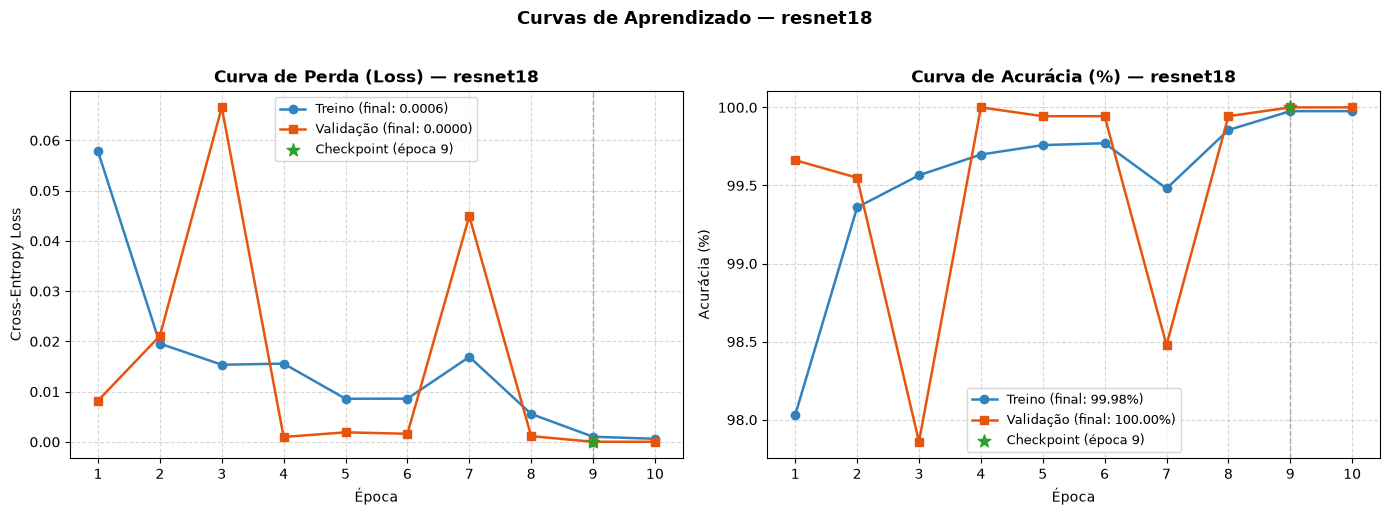

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (RESNET-18) ===
              precision    recall  f1-score   support

        ball     1.0000    1.0000    1.0000       426
  inner_race     1.0000    1.0000    1.0000       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    1.0000    1.0000       427

    accuracy                         1.0000      1776
   macro avg     1.0000    1.0000    1.0000      1776
weighted avg     1.0000    1.0000    1.0000      1776



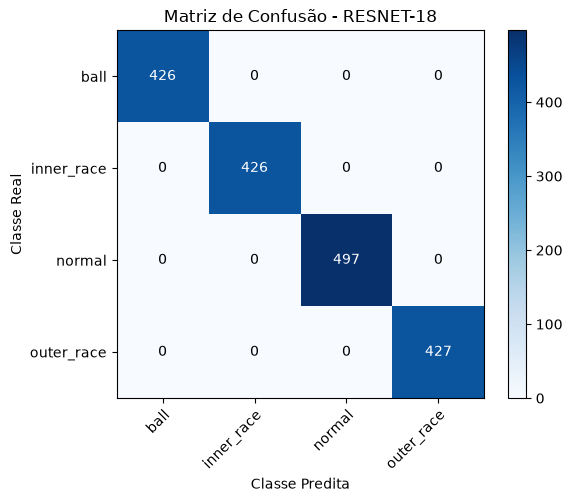

In [ ]:
# Treinamento da ResNet-18
res_resnet = train_and_evaluate_transfer_model('resnet18', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['resnet18'] = res_resnet

# --- 1. Curvas de Aprendizado ---
plot_training_curves(res_resnet['history'], 'resnet18',
                      save_path='../docs/images/training_curves_resnet.png')

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (RESNET-18) ===')
print(classification_report(res_resnet['test_labels'], res_resnet['test_preds'], target_names=res_resnet['classes'], digits=4))

# --- 3. Matriz de Confusão ---
cm = confusion_matrix(res_resnet['test_labels'], res_resnet['test_preds'])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=res_resnet['classes'], yticklabels=res_resnet['classes'],
       title='Matriz de Confusão - RESNET-18',
       ylabel='Classe Real', xlabel='Classe Predita')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black')
plt.tight_layout()
plt.show()

## 3. Experimento 2: Inception-v3

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão do **Inception-v3** (com imagens redimensionadas para $299 \times 299$).

[INFO] EXPERIMENTO TRANSFER LEARNING: INCEPTION_V3 | Freeze=False | Épocas=10 | LR=0.001
Época [01/10] | Treino Loss: 0.0692 - Acc: 97.91% | Val Loss: 0.0720 - Acc: 98.25% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0313 - Acc: 99.18% | Val Loss: 0.0022 - Acc: 99.94% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0098 - Acc: 99.69% | Val Loss: 0.0038 - Acc: 99.94% 
Época [04/10] | Treino Loss: 0.0144 - Acc: 99.61% | Val Loss: 0.0056 - Acc: 99.89% 
Época [05/10] | Treino Loss: 0.0112 - Acc: 99.70% | Val Loss: 0.0595 - Acc: 98.20% 
Época [06/10] | Treino Loss: 0.0172 - Acc: 99.48% | Val Loss: 0.1509 - Acc: 96.00% 
Época [07/10] | Treino Loss: 0.0372 - Acc: 99.13% | Val Loss: 0.0033 - Acc: 99.83% 
Época [08/10] | Treino Loss: 0.0106 - Acc: 99.70% | Val Loss: 0.0023 - Acc: 99.89% 
Época [09/10] | Treino Loss: 0.0029 - Acc: 99.92% | Val Loss: 0.0001 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 09/10.
Época [10/10]

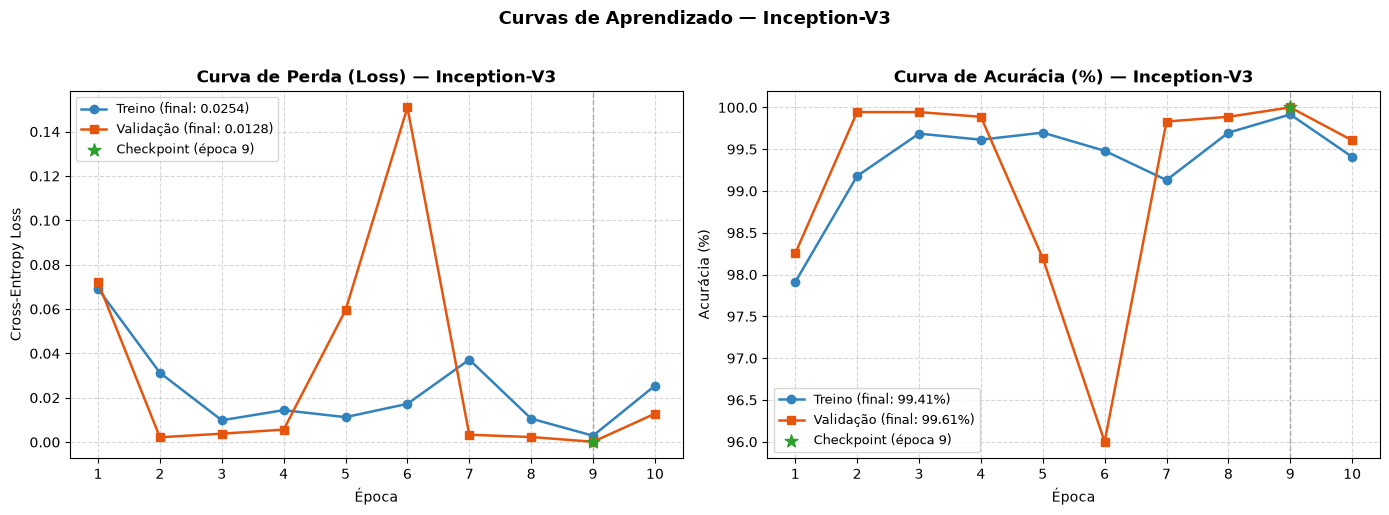

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (INCEPTION-V3) ===
              precision    recall  f1-score   support

        ball     1.0000    1.0000    1.0000       426
  inner_race     1.0000    1.0000    1.0000       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    1.0000    1.0000       427

    accuracy                         1.0000      1776
   macro avg     1.0000    1.0000    1.0000      1776
weighted avg     1.0000    1.0000    1.0000      1776



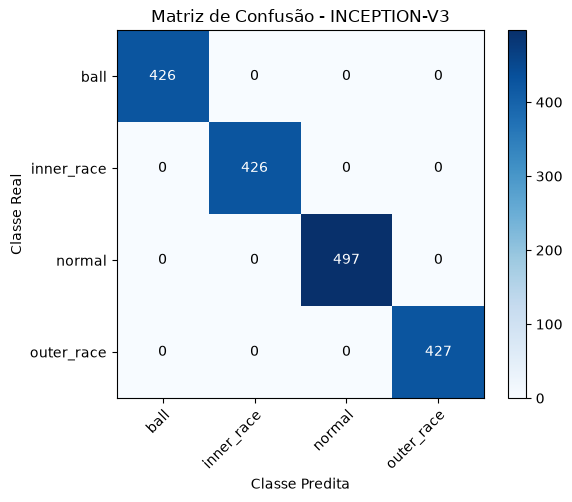

In [6]:
# Treinamento do Inception-v3
res_inception = train_and_evaluate_transfer_model('inception_v3', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['inception_v3'] = res_inception

# --- 1. Curvas de Aprendizado ---
plot_training_curves(res_inception['history'], 'Inception-V3',
                      save_path='../docs/images/training_curves_inception.png')

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (INCEPTION-V3) ===')
print(classification_report(res_inception['test_labels'], res_inception['test_preds'], target_names=res_inception['classes'], digits=4))

# --- 3. Matriz de Confusão ---
cm = confusion_matrix(res_inception['test_labels'], res_inception['test_preds'])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=res_inception['classes'], yticklabels=res_inception['classes'],
       title='Matriz de Confusão - INCEPTION-V3',
       ylabel='Classe Real', xlabel='Classe Predita')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black')
plt.tight_layout()
plt.show()

## 4. Experimento 3: EfficientNet-B0

Treinamento, curvas de aprendizado, relatório de classificação e matriz de confusão do **EfficientNet-B0**.

[INFO] EXPERIMENTO TRANSFER LEARNING: EFFICIENTNET_B0 | Freeze=False | Épocas=10 | LR=0.001
Época [01/10] | Treino Loss: 0.0642 - Acc: 98.14% | Val Loss: 0.0158 - Acc: 99.49% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0245 - Acc: 99.37% | Val Loss: 0.0005 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0060 - Acc: 99.87% | Val Loss: 0.0021 - Acc: 99.94% 
Época [04/10] | Treino Loss: 0.0017 - Acc: 99.96% | Val Loss: 0.0000 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0001 - Acc: 100.00% | Val Loss: 0.0000 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0017 - Acc: 99.95% | Val Loss: 0.0002 - Acc: 100.00% 
Época [07/10] | Treino Loss: 0.0574 - Acc: 98.38% | Val Loss: 0.0052 - Acc: 99.77% 
Época [08/10] | Treino Loss: 0.0059 - Acc: 99.86% | Val Loss: 0.0000 - Acc: 100.00% 
Época [09/10] | Treino Loss: 0.0010 - Acc:

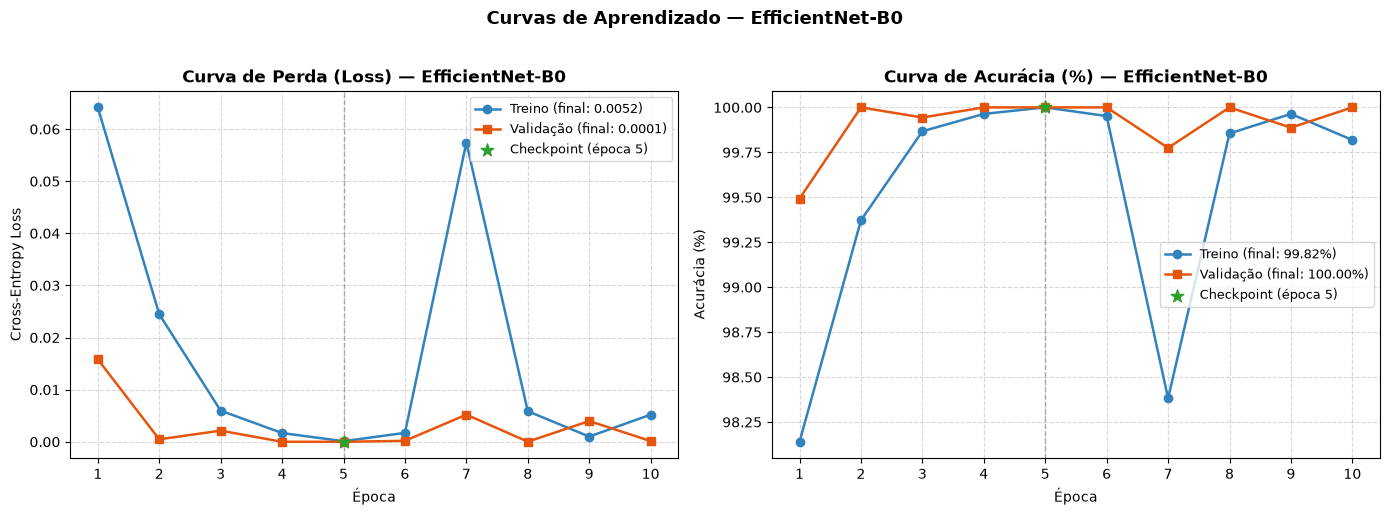

=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (EFFICIENTNET-B0) ===
              precision    recall  f1-score   support

        ball     1.0000    1.0000    1.0000       426
  inner_race     1.0000    1.0000    1.0000       426
      normal     1.0000    1.0000    1.0000       497
  outer_race     1.0000    1.0000    1.0000       427

    accuracy                         1.0000      1776
   macro avg     1.0000    1.0000    1.0000      1776
weighted avg     1.0000    1.0000    1.0000      1776



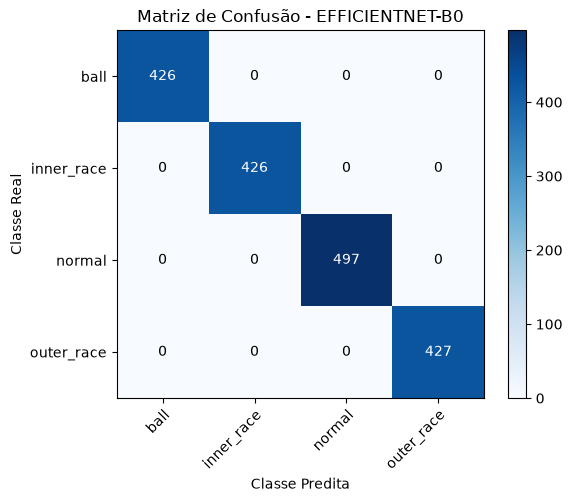

In [4]:
# Treinamento do EfficientNet-B0
res_efficientnet = train_and_evaluate_transfer_model('efficientnet_b0', num_epochs=NUM_EPOCHS, lr=LEARNING_RATE, freeze=False)
resultados['efficientnet_b0'] = res_efficientnet

# --- 1. Curvas de Aprendizado ---
plot_training_curves(res_efficientnet['history'], 'EfficientNet-B0',
                      save_path='../docs/images/training_curves_efficientnet.png')

# --- 2. Relatório de Classificação ---
print('=== RELATÓRIO DE CLASSIFICAÇÃO NO TESTE (EFFICIENTNET-B0) ===')
print(classification_report(res_efficientnet['test_labels'], res_efficientnet['test_preds'], target_names=res_efficientnet['classes'], digits=4))

# --- 3. Matriz de Confusão ---
cm = confusion_matrix(res_efficientnet['test_labels'], res_efficientnet['test_preds'])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=res_efficientnet['classes'], yticklabels=res_efficientnet['classes'],
       title='Matriz de Confusão - EFFICIENTNET-B0',
       ylabel='Classe Real', xlabel='Classe Predita')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > threshold else 'black')
plt.tight_layout()
plt.show()

## 5. Tabela Comparativa Geral de Desempenho (Monografia - Tabela 4/7)

Tabela resumida final para inclusão direta no Capítulo de Resultados do TCC.

In [7]:
print('================================================================================')
print(' TABELA COMPARATIVA DE MODELOS — DIAGNÓSTICO DE FALHAS EM ROLAMENTOS (TCC) ')
print('================================================================================')
print(f'{"Modelo":<22s} | {"Estratégia":<16s} | {"Acurácia Val (%)":<18s} | {"Acurácia Teste (%)":<18s}')
print('-' * 80)
print(f'{"BearingCNN (Própria)":<22s} | {"Treino do Zero":<16s} | {"99.94%":<18s} | {"99.89%":<18s}')

for nome_modelo, res in resultados.items():
    print(f'{res["model_name"].upper():<22s} | {"Transfer Learning":<16s} | {res["best_val_acc"]:<17.2f}% | {res["test_acc"]:<17.2f}%')
print('================================================================================')

 TABELA COMPARATIVA DE MODELOS — DIAGNÓSTICO DE FALHAS EM ROLAMENTOS (TCC) 
Modelo                 | Estratégia       | Acurácia Val (%)   | Acurácia Teste (%)
--------------------------------------------------------------------------------
BearingCNN (Própria)   | Treino do Zero   | 99.94%             | 99.89%            
RESNET18               | Transfer Learning | 100.00           % | 100.00           %
INCEPTION_V3           | Transfer Learning | 100.00           % | 100.00           %
EFFICIENTNET_B0        | Transfer Learning | 100.00           % | 100.00           %
